# Smartphones in India, 2023
## Task 5 · Clustering: which types of phones are there?

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

In Task 4 we *told* the decision tree the price segment of every phone. Now we do the opposite: we give the computer only the specs and let it find groups of similar phones by itself. This is **clustering**, a kind of *unsupervised* learning: there is no right answer to learn from.

> **Which types of phones are on the market, if we look only at their specs? And do these types match the price segments?**

**How we cover the task**

| Requirement | Where |
|---|---|
| A clustering algorithm | **k-means** (Parts 2–4), and **AHC** (hierarchical clustering) as a check (Part 5) |
| Different parameters: at least 5 clusterings | k-means with **k = 1 to 10** (Part 2) |
| Choosing the best clustering | the **Elbow method** and the **silhouette** measure (Part 2) |
| Plotting the clusters | the clusters on a 2-D map (3.3) |
| The centroids and their interpretation | 3.1 and 3.2 |

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# We use the same chart style as in Tasks 1-4 (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
CLUSTER_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]          # four different colours for four clusters
SEGMENTS = ["Budget", "Mid-range", "Premium", "Flagship"]
SEGMENT_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]          # Budget -> Flagship, light to dark (as in Task 2)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})

def save(fig, name):
    # We save every chart to figures/ so it can go straight into our slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

df = pd.read_csv(DATA / "smartphones_clean.csv")
print(f"Clean data from Task 1: {df.shape[0]} phones x {df.shape[1]} columns")

Clean data from Task 1: 907 phones x 61 columns


## Part 1 · Which specs we use, and how we prepare them
**k-means** puts every phone into the group with the nearest **centroid** (the "average phone" of the group), and then moves each centroid to the middle of its group, again and again, until nothing changes. "Nearest" is measured as a distance between the phones' specs, so the preparation matters a lot:

- **12 specs:** processor speed, RAM, storage, battery, fast charging, screen size, refresh rate, main camera, front camera, pixel density, 5G and NFC. **We leave out the price on purpose**: we want groups by specs, and afterwards we check how much each group costs.
- **RAM and storage on a log scale (log₂):** they come in doubling steps (4, 8, 16 GB…), and with log₂ each doubling is one equal step.
- **We cap extreme values** at the 1st and 99th percentile, because k-means is sensitive to outliers: otherwise the rugged phones with batteries of up to 22,000 mAh (Task 1) would pull a centroid towards them.
- **Standardization (z-scores, as in Task 1):** without it, the battery (thousands of mAh) would dominate the distance and the processor speed (2–3 GHz) would hardly count. With z-scores, every spec counts the same.

In [2]:
FEATURES = {"processor_speed": "processor speed (GHz)", "ram_capacity": "RAM (GB)", "internal_memory": "storage (GB)",
            "battery_capacity": "battery (mAh)", "fast_charging": "fast charging (W)", "screen_size": "screen size (inches)",
            "refresh_rate": "refresh rate (Hz)", "primary_camera_rear": "main camera (MP)",
            "primary_camera_front": "front camera (MP)", "ppi": "pixel density (ppi)", "has_5g": "5G", "has_nfc": "NFC"}
LOG2 = ["ram_capacity", "internal_memory"]

X = df[list(FEATURES)].astype(float)
X_prepared = X.copy()
X_prepared[LOG2] = np.log2(X_prepared[LOG2])          # 4 -> 8 -> 16 GB become equal steps
for col in X_prepared:
    if X_prepared[col].nunique() > 2:          # we cap the numeric specs, not the yes/no ones
        low, high = X_prepared[col].quantile([0.01, 0.99])
        X_prepared[col] = X_prepared[col].clip(low, high)

scaler = StandardScaler()
Z = scaler.fit_transform(X_prepared)          # every spec now has mean 0 and standard deviation 1
print(f"{Z.shape[0]} phones x {Z.shape[1]} specs | means: {np.abs(Z.mean(axis=0)).max():.1e} | standard deviations: {Z.std(axis=0).mean():.2f}")

907 phones x 12 specs | means: 1.1e-15 | standard deviations: 1.00


## Part 2 · k-means with different numbers of clusters
k-means needs us to choose **k**, the number of clusters. We try **k = 1 to 10** and judge each clustering in two ways:

- **WCSS (within-cluster sum of squares, called *inertia*):** how far the phones are from their own centroid, all squared distances added up. It always gets smaller with more clusters (with one cluster per phone it would be 0), so we look for the **elbow**: the point after which more clusters bring only small improvements. As a simple rule, we take the first k after which one more cluster lowers the WCSS by less than 10%.
- **Silhouette:** for each phone, we compare *a*, its average distance to the other phones of its own cluster, with *b*, its average distance to the phones of the nearest other cluster: **s = (b − a) / max(a, b)**. It goes from −1 (the phone is in the wrong cluster) to +1 (clearly in its cluster). The average over all phones measures how well separated the clusters are. It needs at least 2 clusters.

k-means starts from random centroids, so we run it 20 times for every k (`n_init=20`) and keep the best result, with a fixed `random_state` so that our results are repeatable.

In [3]:
models, rows = {}, []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Z)
    models[k] = km
    rows.append({"k": k, "WCSS (inertia)": km.inertia_,
                 "silhouette": silhouette_score(Z, km.labels_) if k > 1 else np.nan,
                 "smallest cluster (phones)": np.bincount(km.labels_).min()})
results = pd.DataFrame(rows).set_index("k")
# How much one more cluster lowers the WCSS
results["WCSS drop with one more cluster"] = 1 - results["WCSS (inertia)"].shift(-1) / results["WCSS (inertia)"]

# The elbow: the smallest k after which one more cluster lowers the WCSS by less than 10%
elbow_k = int(results.index[results["WCSS drop with one more cluster"] < 0.10][0])
print(f"Elbow: k = {elbow_k} (one more cluster lowers the WCSS by only "
      f"{results.loc[elbow_k, 'WCSS drop with one more cluster']:.1%})")
print(f"Best silhouette: k = {results['silhouette'].idxmax()} ({results['silhouette'].max():.3f}) | "
      f"best silhouette for k >= 3: k = {results.loc[3:, 'silhouette'].idxmax()} ({results.loc[3:, 'silhouette'].max():.3f})")
k2 = models[2].labels_          # what do the 2 clusters look like?
for label in np.argsort(df.groupby(k2)["price_eur"].median().values):
    part = df[k2 == label]
    print(f"k = 2, cluster with {len(part)} phones: median price {part['price_eur'].median():.0f} EUR, with 5G {part['has_5g'].mean():.0%}")
results.style.format({"WCSS (inertia)": "{:,.0f}", "silhouette": "{:.3f}", "WCSS drop with one more cluster": "{:.1%}"},
                     na_rep="")

Elbow: k = 4 (one more cluster lowers the WCSS by only 8.8%)
Best silhouette: k = 2 (0.287) | best silhouette for k >= 3: k = 4 (0.235)
k = 2, cluster with 401 phones: median price 133 EUR, with 5G 13%
k = 2, cluster with 506 phones: median price 333 EUR, with 5G 88%


,WCSS (inertia),silhouette,smallest cluster (phones),WCSS drop with one more cluster
k,,,,
1,"10,884",,907,33.1%
2,"7,278",0.287,401,13.9%
3,"6,267",0.212,219,12.0%
4,"5,517",0.235,75,8.8%
5,"5,030",0.234,32,8.2%
6,"4,618",0.220,30,6.4%
7,"4,322",0.221,29,5.5%
8,"4,083",0.228,28,5.2%
9,"3,871",0.222,17,4.8%


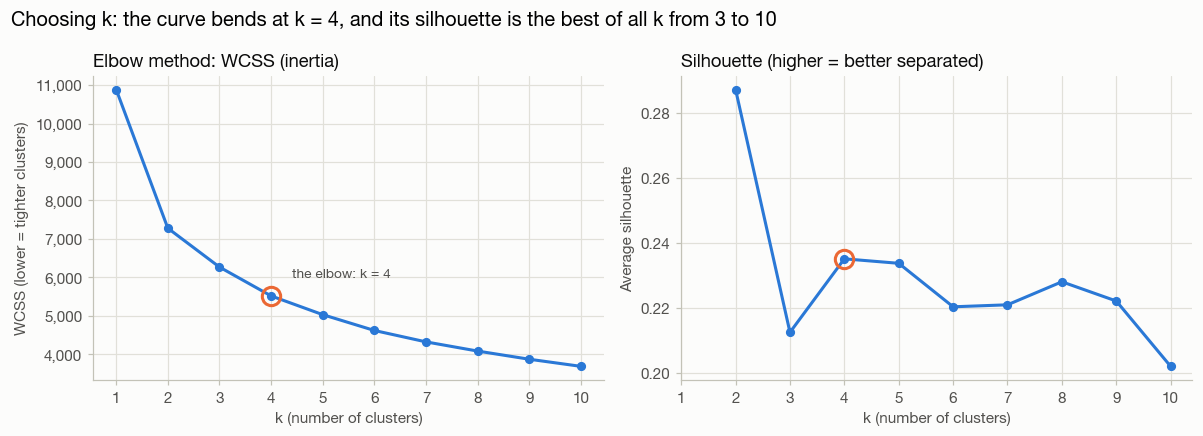

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(results.index, results["WCSS (inertia)"], color=BLUE, marker="o", markersize=5)
ax.plot(elbow_k, results.loc[elbow_k, "WCSS (inertia)"], "o", markersize=12, markerfacecolor="none",
        markeredgecolor=ORANGE, markeredgewidth=2)
ax.annotate(f"the elbow: k = {elbow_k}", (elbow_k, results.loc[elbow_k, "WCSS (inertia)"]), xytext=(14, 12),
            textcoords="offset points", fontsize=9, color=INK2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Elbow method: WCSS (inertia)")
ax.set_ylabel("WCSS (lower = tighter clusters)")

ax = axes[1]
sil = results["silhouette"].dropna()
ax.plot(sil.index, sil.values, color=BLUE, marker="o", markersize=5)
ax.plot(elbow_k, results.loc[elbow_k, "silhouette"], "o", markersize=12, markerfacecolor="none",
        markeredgecolor=ORANGE, markeredgewidth=2)
ax.set_title("Silhouette (higher = better separated)")
ax.set_ylabel("Average silhouette")
for ax in axes:
    ax.set_xticks(range(1, 11))
    ax.set_xlabel("k (number of clusters)")
fig.suptitle(f"Choosing k: the curve bends at k = {elbow_k}, and its silhouette is the best of all k from 3 to 10",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t5_01_elbow_silhouette")
plt.show()

- **Elbow method:** the WCSS falls steeply at first: one more cluster lowers it by 33.1% (from 1 to 2 clusters), 13.9% (2 → 3) and 12.0% (3 → 4). After k = 4, every extra cluster lowers it by less than 9% (8.8% for 4 → 5, then 8.2%, 6.4%, …). So the curve bends at **k = 4**: from there on, more clusters bring only small improvements.
- **Silhouette:** the highest value is for k = 2 (0.287). But two clusters only split the market roughly into cheaper phones, mostly without 5G (401 phones, median €133, 13% with 5G), and 5G phones (506 phones, median €333, 88% with 5G). That is too rough to describe the market. Among k = 3 to 10, the best silhouette is at **k = 4 (0.235)**, with k = 5 almost the same (0.234).
- So **we choose k = 4**.

The silhouette values are low for every k (0.20–0.29). Phones don't form separate islands: they form a continuum from simple to powerful phones, so the clusters have soft borders. This is normal for real market data.

**What would k = 5 add?** To check our choice, we compare the 4 clusters with the 5 clusters (rows: k = 4, columns: k = 5):

In [5]:
k4, k5 = models[4].labels_, models[5].labels_
# We name the 4 clusters from the cheapest to the most expensive, as in Part 3
names_k4 = dict(zip(df.groupby(k4)["price_eur"].mean().sort_values().index, ["Basic", "Everyday", "Performance", "Compact premium"]))
display(pd.crosstab(pd.Series([names_k4[l] for l in k4], name="k = 4 cluster"), pd.Series(k5 + 1, name="k = 5 cluster"))
        .reindex(["Basic", "Everyday", "Performance", "Compact premium"]))
new_group = pd.Series(k5).value_counts().idxmin()          # the smallest of the 5 clusters
profile = X[k5 == new_group].mean()
print(f"The smallest of the 5 clusters: {(k5 == new_group).sum()} phones | screen {profile['screen_size']:.1f} inches, "
      f"RAM {profile['ram_capacity']:.1f} GB, storage {profile['internal_memory']:.0f} GB, battery {profile['battery_capacity']:,.0f} mAh, "
      f"refresh rate {profile['refresh_rate']:.0f} Hz, 5G {profile['has_5g']:.0%} | median price {df.loc[k5 == new_group, 'price_eur'].median():.0f} EUR")
print("Its phones:", ", ".join(sorted(df.loc[k5 == new_group, "model"])))

k = 5 cluster,1,2,3,4,5
k = 4 cluster,,,,,
Basic,0,188,0,0,21
Everyday,3,37,300,0,0
Performance,16,0,15,252,0
Compact premium,64,0,0,0,11


The smallest of the 5 clusters: 32 phones | screen 5.5 inches, RAM 2.8 GB, storage 39 GB, battery 3,173 mAh, refresh rate 60 Hz, 5G 3% | median price 87 EUR
Its phones: Apple iPhone 11, Apple iPhone SE 2020, Apple iPhone SE 3 2022, CAT S22 Flip, Duoqin F22 Pro, Gionee G13 Pro, Google Pixel 3a XL, Huawei Honor 9N, Itel A23 Pro, Itel A24 Pro, Jio JioPhone Next, Jio JioPhone Next (3GB RAM + 32GB), Lyf Earth 1, Lyf Earth 2, Nokia C01 Plus, OPPO A73, Realme C2, Realme C2s, Samsung Galaxy A01 Core, Samsung Galaxy A40, Samsung Galaxy A7 (2018), TCL Ion X, Tecno Pop 5 Go, Vivo V11i, Vivo Y25, Vivo Y55S, Vivo Y71, Vivo Y91c, Xiaomi Redmi Note 4, itel A23s, itel A56, itel Vision 1 (3GB RAM + 32GB)


k = 5 doesn't find a new type of phone. It only splits off **32 small, simple phones** (on average a 5.5-inch 60 Hz screen, a 3,173 mAh battery, about 3 GB of RAM and 39 GB of storage; 3% with 5G; median price €87). These are older or entry-level models, such as the iPhone SE 2020, the Samsung Galaxy A7 (2018) and the JioPhone Next. They come from the Basic (21) and Compact premium (11) clusters, and the other clusters stay mostly the same. So k = 4 gives the clearer picture.

## Part 3 · Our 4 clusters
We give each cluster a name that describes its centroid (see 3.1), and we sort them from the cheapest to the most expensive (by their mean price).

In [6]:
k_final = 4
km = models[k_final]
mean_price = df.groupby(km.labels_)["price_eur"].mean().sort_values()
NAMES = ["Basic", "Everyday", "Performance", "Compact premium"]          # from the cheapest to the most expensive
name_of = {label: NAMES[i] for i, label in enumerate(mean_price.index)}
df["cluster"] = pd.Categorical([name_of[label] for label in km.labels_], categories=NAMES, ordered=True)

sizes = df.groupby("cluster", observed=True).agg(phones=("model", "size"), mean_price=("price_eur", "mean"),
                                                median_price=("price_eur", "median"), cheapest=("price_eur", "min"),
                                                most_expensive=("price_eur", "max"))
sizes.insert(1, "share", sizes["phones"] / len(df))
sizes.style.format({"share": "{:.1%}", "mean_price": "€{:,.0f}", "median_price": "€{:,.0f}", "cheapest": "€{:,.0f}",
                    "most_expensive": "€{:,.0f}"})

,phones,share,mean_price,median_price,cheapest,most_expensive
cluster,,,,,,
Basic,209,23.0%,€113,€105,€39,€288
Everyday,340,37.5%,€209,€189,€98,"€1,667"
Performance,283,31.2%,€555,€411,€189,"€2,033"
Compact premium,75,8.3%,€690,€622,€43,"€1,922"


### 3.1 The centroids
The **centroid** of a cluster is its "average phone". k-means computes it in z-scores (0 = the average phone of the whole market, +1 = one standard deviation above it). The heatmap shows these values; red means above the market average, blue below.

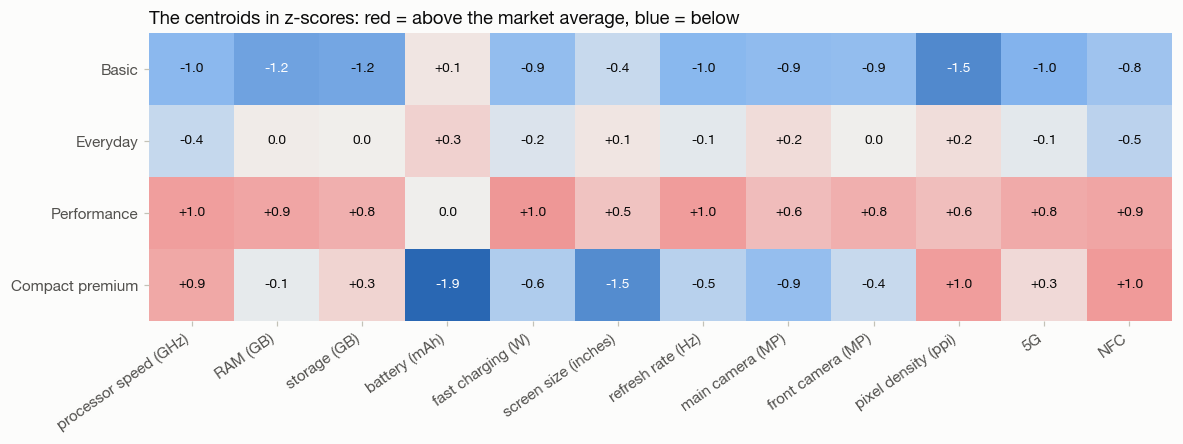

In [7]:
centroids_z = pd.DataFrame(km.cluster_centers_, columns=[FEATURES[f] for f in FEATURES])
centroids_z.index = [name_of[i] for i in range(k_final)]
centroids_z = centroids_z.reindex(NAMES)

diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f19c9b", "#c23736"])
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.imshow(centroids_z.values, cmap=diverging, vmin=-2, vmax=2, aspect="auto")
for i in range(centroids_z.shape[0]):
    for j in range(centroids_z.shape[1]):
        v = centroids_z.values[i, j]
        ax.text(j, i, f"{v:+.1f}" if abs(v) >= 0.05 else "0.0", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 1.2 else INK)
ax.set_xticks(range(centroids_z.shape[1]), centroids_z.columns, rotation=35, ha="right")
ax.set_yticks(range(len(NAMES)), NAMES)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("The centroids in z-scores: red = above the market average, blue = below")
save(fig, "t5_02_centroids")
plt.show()

To read the centroids in real units, we undo our preparation (the standardization and the log₂ scale). For 5G and NFC, the centroid is the **share of phones** in the cluster that have it.

In [8]:
centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=list(FEATURES))
centroids[LOG2] = 2 ** centroids[LOG2]          # back from log2 to GB
centroids.index = [name_of[i] for i in range(k_final)]
centroids = centroids.reindex(NAMES)
centroids["price (median, not used for clustering)"] = sizes["median_price"]
centroids.rename(columns=FEATURES).T.style.format("{:,.1f}").format(
    "{:.0%}", subset=pd.IndexSlice[["5G", "NFC"], :]).format("€{:,.0f}", subset=pd.IndexSlice[["price (median, not used for clustering)"], :])

,Basic,Everyday,Performance,Compact premium
processor speed (GHz),2.0,2.2,2.9,2.8
RAM (GB),3.5,6.1,8.7,5.7
storage (GB),54.9,114.7,183.0,139.1
battery (mAh),"4,836.7","4,978.6","4,768.6","3,649.6"
fast charging (W),8.2,30.3,70.7,17.1
screen size (inches),6.4,6.6,6.7,6.1
refresh rate (Hz),64.4,88.1,119.4,76.8
main camera (MP),21.2,56.4,68.1,22.5
front camera (MP),7.0,16.2,24.4,12.2
pixel density (ppi),273.8,392.1,418.3,444.9


**Our interpretation of the four centroids:**
- **Basic** (209 phones, 23%): the slowest processors (2.0 GHz), about 3.5 GB of RAM and 55 GB of storage, little or no fast charging (8 W on average), mostly 60 Hz screens with a low pixel density (274 ppi), simple cameras, and almost never 5G or NFC (4% and 2%). Median price **€105**.
- **Everyday** (340 phones, 38%): the typical phone of the market, with most z-scores close to 0. About 6 GB of RAM and 115 GB of storage, 30 W charging, 88 Hz on average, a 56 MP main camera, 5G in half of them (49%) but NFC only in 15%. Median price **€189**.
- **Performance** (283 phones, 31%): above the market average in every spec except the battery, which is average. Fast processors (2.9 GHz), about 9 GB of RAM, 71 W charging, 120 Hz screens, the best cameras (68 MP main, 24 MP front), 5G (96%) and NFC (82%). Median price **€411**.
- **Compact premium** (75 phones, 8%): fast processors (2.8 GHz), sharp screens (445 ppi) and NFC (88%), but **small**: 6.1-inch screens, the smallest batteries (3,650 mAh), slow charging (17 W) and simpler cameras (22.5 MP main, 12 MP front). This is the profile of an iPhone or a small Android flagship (see 3.2). Median price **€622**, the highest of all four.

### 3.2 Typical phones of each cluster
The phones closest to each centroid are the most typical members of their cluster. We also count the iPhones and foldables in each cluster.

In [9]:
distance = np.linalg.norm(Z - km.cluster_centers_[km.labels_], axis=1)          # each phone's distance to its own centroid
df["distance_to_centroid"] = distance
typical = df.sort_values("distance_to_centroid").groupby("cluster", observed=True).head(3)
display(typical.sort_values(["cluster", "distance_to_centroid"])[["cluster", "model", "price_eur"]]
        .style.format({"price_eur": "€{:,.0f}"}).hide(axis="index"))
print("iPhones in the Performance cluster:", ", ".join(df.loc[(df["cluster"] == "Performance") & (df["brand_name"] == "apple"), "model"]))
brands = df.loc[df["cluster"] == "Compact premium", "brand_name"].value_counts()
print("Brands in Compact premium:", ", ".join(f"{b.capitalize()} {n}" for b, n in brands.head(4).items()), f"| other brands {brands.iloc[4:].sum()}")
df.groupby("cluster", observed=True).agg(phones=("model", "size"), iPhones=("brand_name", lambda b: (b == "apple").sum()),
                                         foldables=("is_foldable", lambda f: (f == "Yes").sum()))

cluster,model,price_eur
Basic,Xiaomi Redmi 9i Sport,€83
Basic,Vivo Y20G,€155
Basic,Vivo Y12G (3GB RAM + 64GB),€133
Everyday,OPPO K10,€150
Everyday,Realme 9i (6GB RAM + 128GB),€167
Everyday,Poco M4 Pro 5G (6GB RAM + 128GB),€167
Performance,Poco F4 5G (8GB RAM + 128GB),€311
Performance,OnePlus Ace Racing Edition 5G,€255
Performance,Xiaomi Civi 3,€367
Compact premium,Apple iPhone 14,€733


iPhones in the Performance cluster: Apple iPhone 14 Pro Max, Apple iPhone 15 Pro Max, Apple iPhone 14 Pro Max (256GB), Apple iPhone 14 Pro Max (1TB), Apple iPhone 13 Pro Max (256GB), Apple iPhone 14 Pro Max (512GB), Apple iPhone 13 Pro Max (1TB), Apple iPhone 15 Plus
Brands in Compact premium: Apple 32, Samsung 18, Google 9, Sony 5 | other brands 11


,phones,iPhones,foldables
cluster,,,
Basic,209,0,0
Everyday,340,0,2
Performance,283,8,15
Compact premium,75,32,2


The most typical phones fit the names: the Basic centroid is closest to the Xiaomi Redmi 9i Sport (€83), Everyday to the OPPO K10 and the Realme 9i, Performance to the Poco F4 5G and the OnePlus Ace Racing Edition, and Compact premium to the **iPhone 14, the iPhone 12 and the Google Pixel 7a**.

**k-means put most iPhones together, although it never saw the brand:** 32 of the 40 iPhones are in Compact premium. The other 8 are the big Pro Max and Plus models, which fall into Performance. The rest of Compact premium are mostly compact Android phones from Samsung (18), Google (9) and Sony (5). Most foldables (15 of 19) are in Performance.

### 3.3 Plotting the clusters
Our phones have 12 specs, so we can't draw them directly. **PCA (principal component analysis)** turns the 12 specs into new axes that keep as much of the differences between the phones as possible. We draw the first two: each dot is a phone, and the large circles are the centroids.

Share of the differences between phones that the map keeps: PC1 47.4%, PC2 14.6%, together 62.0%


,RAM (GB),storage (GB),processor speed (GHz),fast charging (W),refresh rate (Hz),5G,pixel density (ppi),NFC,front camera (MP),main camera (MP),screen size (inches),battery (mAh)
PC1,0.360,0.340,0.330,0.330,0.330,0.310,0.300,0.270,0.260,0.250,0.190,0.010
PC2,0.050,-0.010,-0.190,0.100,0.110,-0.130,-0.230,-0.300,-0.020,0.280,0.520,0.660


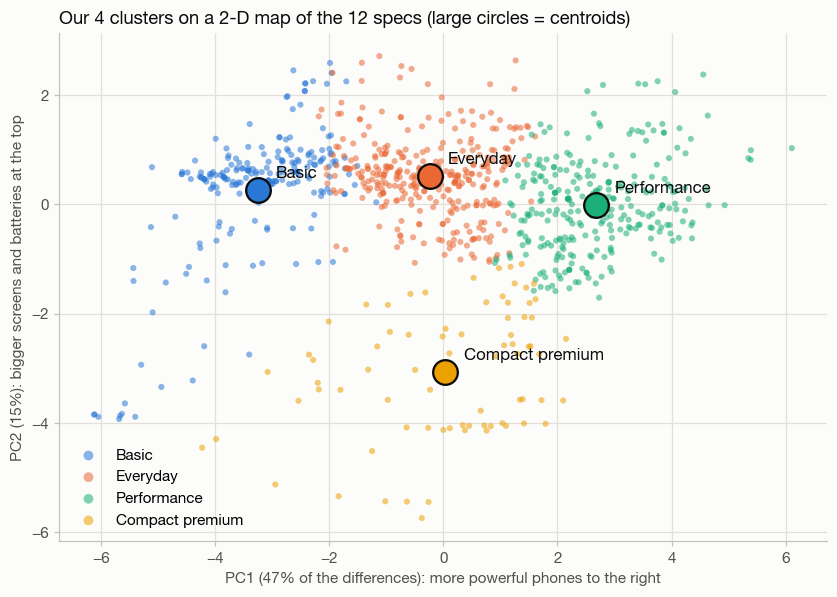

In [10]:
pca = PCA(n_components=2, random_state=42).fit(Z)
points = pca.transform(Z)
centres = pca.transform(km.cluster_centers_)
loadings = pd.DataFrame(pca.components_.T, index=[FEATURES[f] for f in FEATURES], columns=["PC1", "PC2"])
print(f"Share of the differences between phones that the map keeps: PC1 {pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2 {pca.explained_variance_ratio_[1]:.1%}, together {pca.explained_variance_ratio_.sum():.1%}")
display(loadings.round(2).sort_values("PC1", ascending=False).T)

fig, ax = plt.subplots(figsize=(9, 6))
for i, name in enumerate(NAMES):
    mask = (df["cluster"] == name).values
    ax.scatter(points[mask, 0], points[mask, 1], s=16, color=CLUSTER_COLORS[i], alpha=0.55, edgecolors="none", label=name)
for label in range(k_final):
    i = NAMES.index(name_of[label])
    ax.scatter(*centres[label], s=260, color=CLUSTER_COLORS[i], edgecolors=INK, linewidths=1.5, zorder=3)
    ax.annotate(name_of[label], centres[label], xytext=(12, 8), textcoords="offset points", fontsize=11,
                fontweight="semibold", color=INK, zorder=4)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of the differences): more powerful phones to the right")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%}): bigger screens and batteries at the top")
ax.set_title("Our 4 clusters on a 2-D map of the 12 specs (large circles = centroids)")
ax.legend(loc="lower left", markerscale=1.6)
save(fig, "t5_03_clusters_map")
plt.show()

- The map keeps **62%** of the differences between the phones (PC1 47%, PC2 15%), so it is a good, but not perfect, picture of the 12 specs.
- **PC1 is the overall level of a phone:** all specs except the battery push it to the right, most of all RAM, storage, processor speed, fast charging and refresh rate.
- **PC2 separates big phones from compact ones:** big batteries and screens push a phone up, while NFC and a sharp screen pull it down.
- The clusters line up from left to right: **Basic → Everyday → Performance**. **Compact premium** sits apart at the bottom: small phones with small batteries, in the middle on PC1.
- The clusters touch each other, so there are no sharp borders between the types.

### 3.4 How well is each phone placed? The silhouette plot
Each bar is one phone, sorted by its silhouette value within its cluster. Long bars to the right = clearly in the right cluster; bars to the left of 0 = the phone is closer to another cluster.

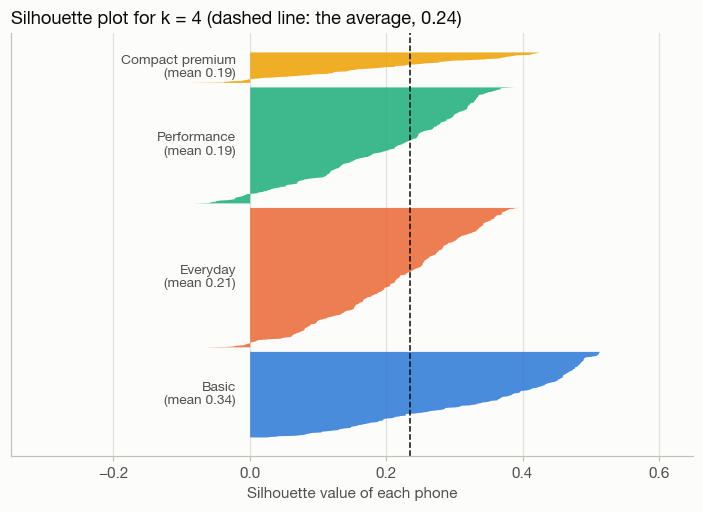

Phones with a negative silhouette (closer to another cluster): 44 of 907 (4.9%) | by cluster: {'Basic': 0, 'Everyday': 10, 'Performance': 24, 'Compact premium': 10}


In [11]:
values = silhouette_samples(Z, km.labels_)
df["silhouette"] = values
fig, ax = plt.subplots(figsize=(8, 5))
y_start = 0
for i, name in enumerate(NAMES):
    v = np.sort(df.loc[df["cluster"] == name, "silhouette"].values)
    ax.fill_betweenx(np.arange(y_start, y_start + len(v)), 0, v, color=CLUSTER_COLORS[i], alpha=0.85, linewidth=0)
    ax.text(-0.02, y_start + len(v) / 2, f"{name}\n(mean {v.mean():.2f})", ha="right", va="center", fontsize=9, color=INK2)
    y_start += len(v) + 10
average = values.mean()
ax.axvline(average, color=INK, linewidth=1, linestyle="--")
ax.set_yticks([])
ax.set_xlim(-0.35, 0.65)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Silhouette value of each phone")
ax.set_title(f"Silhouette plot for k = 4 (dashed line: the average, {average:.2f})")
save(fig, "t5_04_silhouette_plot")
plt.show()
print(f"Phones with a negative silhouette (closer to another cluster): {(values < 0).sum()} of {len(values)} ({(values < 0).mean():.1%}) | "
      f"by cluster: {df.loc[values < 0, 'cluster'].value_counts().reindex(NAMES).to_dict()}")

**Basic is the clearest cluster** (mean silhouette 0.34): basic phones are very different from all others, and none of them has a negative silhouette. The other three clusters overlap more (0.19–0.21). Only 44 phones (4.9%) have a negative silhouette, which means they are closer to another cluster than to their own. These are phones on the border between two types, most of them in Performance (24).

## Part 4 · Do the clusters match the price segments?
We didn't give k-means the price. So how much do the phones in each cluster cost, and how do the clusters compare with our four price segments from Task 1?

phones (share of the cluster),Budget,Mid-range,Premium,Flagship
cluster,,,,
Basic,191 (91%),18 (9%),0 (0%),0 (0%)
Everyday,130 (38%),201 (59%),5 (1%),4 (1%)
Performance,0 (0%),94 (33%),124 (44%),65 (23%)
Compact premium,5 (7%),11 (15%),25 (33%),34 (45%)


Adjusted Rand index between clusters and price segments: 0.30 (0 = no agreement beyond chance, 1 = the same groups)


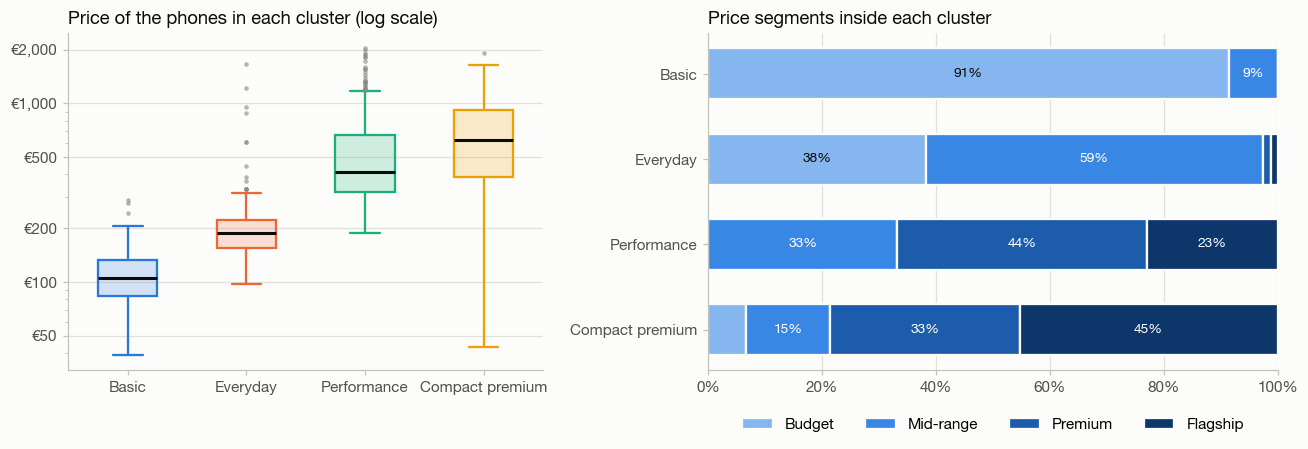

In [12]:
crosstab = pd.crosstab(df["cluster"], df["price_segment"])[SEGMENTS]
shares = crosstab.div(crosstab.sum(axis=1), axis=0)          # the share of each price segment inside each cluster
display((crosstab.astype(str) + " (" + shares.map("{:.0%}".format) + ")").rename_axis(columns="phones (share of the cluster)"))
ari = adjusted_rand_score(df["price_segment"], df["cluster"])
print(f"Adjusted Rand index between clusters and price segments: {ari:.2f} (0 = no agreement beyond chance, 1 = the same groups)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.2]})
ax = axes[0]
groups = [df.loc[df["cluster"] == name, "price_eur"] for name in NAMES]
box = ax.boxplot(groups, patch_artist=True, widths=0.5, medianprops=dict(color=INK, linewidth=2),
                 flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6))
for patch, whisker_pair, color in zip(box["boxes"], range(len(NAMES)), CLUSTER_COLORS):
    patch.set(facecolor=color + "33", edgecolor=color, linewidth=1.5)
for i, color in enumerate(CLUSTER_COLORS):
    for part in ("whiskers", "caps"):
        for line in box[part][2 * i: 2 * i + 2]:
            line.set(color=color, linewidth=1.5)
ax.set_yscale("log")
ax.set_yticks([50, 100, 200, 500, 1000, 2000])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
ax.set_xticks(range(1, len(NAMES) + 1), NAMES)
ax.grid(axis="x", visible=False)
ax.set_title("Price of the phones in each cluster (log scale)")

ax = axes[1]
left = np.zeros(len(shares))
for segment, color in zip(SEGMENTS, SEGMENT_COLORS):
    ax.barh(NAMES, shares[segment].values, left=left, height=0.6, color=color, edgecolor=SURFACE, linewidth=1.5, label=segment)
    for yy, (start, v) in enumerate(zip(left, shares[segment].values)):
        if v >= 0.08:
            ax.text(start + v / 2, yy, f"{v:.0%}", ha="center", va="center", fontsize=9,
                    color=INK if color == SEGMENT_COLORS[0] else "white")
    left += shares[segment].values
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title("Price segments inside each cluster")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
save(fig, "t5_05_clusters_vs_price")
plt.show()

Although k-means never saw the price, **the clusters are clearly ordered by price**: median €105 (Basic), €189 (Everyday), €411 (Performance) and €622 (Compact premium).
- **Basic** phones are almost all Budget phones (91%), and **Everyday** phones are Budget or Mid-range (38% and 59%).
- **Performance** phones are spread over three segments: Mid-range (33%), Premium (44%) and Flagship (23%). Phones with this specs profile cost anything from €189 to €2,033.
- **Compact premium** is the most expensive cluster, with the highest share of flagships (45%).
- The adjusted Rand index between the clusters and the price segments is only 0.30: the clusters are **types of phones**, not price levels. This fits Tasks 3 and 4: the specs explain a lot of the price, but not all of it. The brand matters too (in Task 3, an iPhone costs 2.5 times as much as an Android phone with the same specs).

## Part 5 · A check with another algorithm: hierarchical clustering (AHC)
**Agglomerative hierarchical clustering (AHC)** works differently from k-means: it starts with every phone as its own cluster and merges the two closest clusters again and again, until only one is left. With **Ward's method**, it always merges the two clusters whose merge increases the WCSS the least. The **dendrogram** shows all the merges; cutting it at a certain height gives the clusters. If AHC finds similar groups, our k-means clusters are not just an accident of the method.

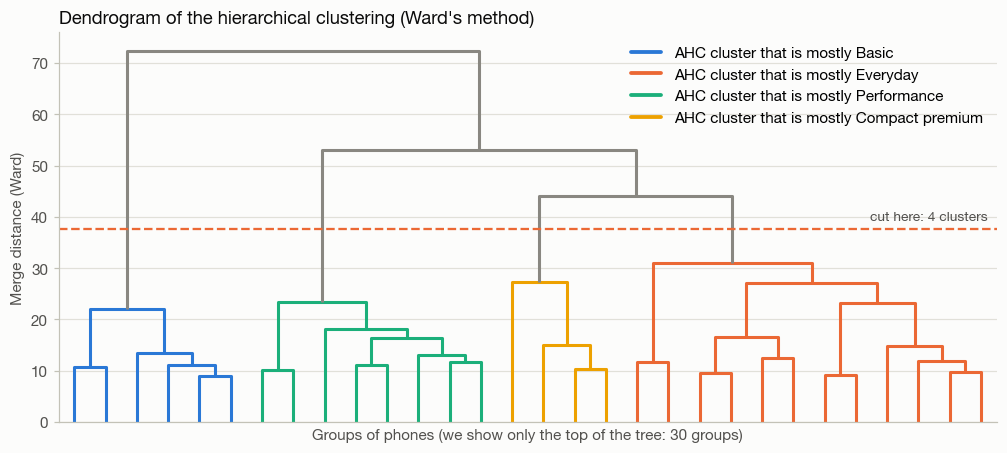

Silhouette: AHC 0.209 vs k-means 0.235 | agreement between the two (adjusted Rand index): 0.58


AHC cluster,mostly Basic,mostly Everyday,mostly Performance,mostly Compact premium
k-means cluster,,,,
Basic,192,5,0,12
Everyday,22,314,3,1
Performance,0,87,196,0
Compact premium,0,24,0,51


In [13]:
tree = linkage(Z, method="ward")
cut_height = (tree[-4, 2] + tree[-3, 2]) / 2          # between the merge that leaves 4 clusters and the one that leaves 3
ahc = fcluster(tree, t=cut_height, criterion="distance")          # the AHC cluster (1-4) of every phone

# We name each AHC cluster after the k-means cluster it overlaps most, and give it the same colour
match = pd.crosstab(ahc, df["cluster"]).idxmax(axis=1)
members = {i: [i] for i in range(len(Z))}          # which phones are under each node of the dendrogram
for step, (a, b, _, _) in enumerate(tree):
    members[len(Z) + step] = members[int(a)] + members[int(b)]
def link_colour(node):
    below = set(ahc[members[node]])
    return CLUSTER_COLORS[NAMES.index(match[below.pop()])] if len(below) == 1 else MUTED

fig, ax = plt.subplots(figsize=(11, 4.6))
dendrogram(tree, truncate_mode="lastp", p=30, link_color_func=link_colour, no_labels=True, ax=ax)
ax.legend(handles=[Line2D([0], [0], color=CLUSTER_COLORS[NAMES.index(name)], linewidth=2.5, label=f"AHC cluster that is mostly {name}")
                   for name in NAMES if name in match.values], loc="upper right")
ax.axhline(cut_height, color=ORANGE, linewidth=1.5, linestyle="--")
ax.annotate("cut here: 4 clusters", (ax.get_xlim()[1], cut_height), xytext=(-6, 6), textcoords="offset points",
            ha="right", fontsize=9, color=INK2)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Merge distance (Ward)")
ax.set_xlabel("Groups of phones (we show only the top of the tree: 30 groups)")
ax.set_title("Dendrogram of the hierarchical clustering (Ward's method)")
save(fig, "t5_06_dendrogram")
plt.show()

print(f"Silhouette: AHC {silhouette_score(Z, ahc):.3f} vs k-means {silhouette_score(Z, km.labels_):.3f} | "
      f"agreement between the two (adjusted Rand index): {adjusted_rand_score(km.labels_, ahc):.2f}")
ahc_names = pd.Series([f"mostly {match[a]}" for a in ahc], name="AHC cluster", index=df.index)
pd.crosstab(df["cluster"], ahc_names).rename_axis("k-means cluster")[[f"mostly {name}" for name in NAMES]]

- **AHC finds the same four types:** each AHC cluster has a clear k-means partner (the colours in the dendrogram).
- **The dendrogram shows the order of the big divides in the market:** its first split separates the **Basic** phones from all others, the second one the **Performance** phones, and the third one splits the rest into **Compact premium** and **Everyday**.
- **The agreement is good but not perfect** (adjusted Rand index 0.58): AHC puts 87 of the Performance phones together with the Everyday phones, so it draws the border between these two types at a higher level.
- k-means has the better silhouette (0.235 vs 0.209), so we keep the k-means clusters.

# Summary of Task 5

| Step | What we did and found |
|---|---|
| Data | 907 phones, 12 specs (no price); log₂ for RAM and storage, extreme values capped, z-scores |
| Clusterings tested | k-means with k = 1 to 10 (20 random starts each) |
| Choosing k | **Elbow:** after k = 4, every extra cluster lowers the WCSS by less than 9%. **Silhouette:** for k ≥ 3, the best is k = 4 (0.235) |
| Our 4 clusters | Basic (23%, median €105), Everyday (38%, €189), Performance (31%, €411), Compact premium (8%, €622) |
| Clusters vs price segments | ordered by price, but they are types, not price levels (adjusted Rand index 0.30) |
| Check with AHC (Ward) | the same 4 types (adjusted Rand index 0.58); k-means has the better silhouette |

**Our answer:** judged by their specs alone, there are **four types of phones**:
- **Basic phones:** cheap, slow, no 5G.
- **Everyday phones:** the typical, middle phone: about 6 GB of RAM, and half of them have 5G.
- **Performance phones:** fast, 120 Hz, with 5G and NFC.
- **Compact premium phones:** small and sharp, with NFC: most iPhones, and compact phones from Samsung, Google and Sony.

k-means found them without seeing the price, and still the four types are ordered by price: the specs say a lot about what a phone costs. And just like in Tasks 2–4, **the iPhones stand out**: k-means put 32 of the 40 iPhones into one cluster without seeing the brand, because they are built differently (small batteries and 12 MP cameras, as we saw in Tasks 2 and 4).

**What we keep in mind**
- **Soft borders:** the silhouette is only 0.24, because phones form a continuum, not separate groups.
- **Our choices matter:** with other specs or another scaling, k-means would find somewhat different clusters.
- **The 2-D map** keeps 62% of the differences between the phones, so some phones that look close on the map are not close in all 12 specs.